![lop](../../../images/logo_diive1_128px.png)

<span style='font-size:24px; display:block;'>Self-heating correction for open-path IRGA fluxes (NEE)</span>
<span style='font-size:40px; display:block;'><b>Create scaling factors table from time period of parallel measurements</b></span> 

---
**Notebook version**: `1` (13 Jan 2026)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

</br>

# General info

- Calculates scaling factors for self-heating correction of open-path fluxes from parallel en-closed path IRGA measurements (NEE)
- Here the scaling factors are calculated from parallel measurements
- Scaling factors are determined in 20 classes of USTAR, separately for daytime and nighttime data
- The scaling factors corresponds to the fraction of the (unscaled) flux correction term that is added to the measured open-path flux NEE
- Step 1: Calculate unscaled flux correction term with `ScopPhysics`
- Step 2: Optimize scaling factors with `ScopOptimizer` (creates **scaling factors table**)
- Step 3: Correct open-path fluxes with `ScopApplicator` (applies **scaling factors table**)
- The **scaling factors table** can be used as look-up table to correct open-path fluxes during time periods without parallel measurements, when only open-path fluxes are available.
- See also the notebook [SelfHeatingCorrectionNEE_2_ApplyScalingFactorsTable](SelfHeatingCorrectionNEE_2_ApplyScalingFactorsTable.ipynb) for an example of how the scaling factors table created here is applied to other time periods

</br>

</br>

# Imports

In [5]:
from datetime import datetime
import pandas as pd
from diive.core.io.files import save_parquet, load_parquet
from diive.pkgs.flux.selfheating import ScopPhysics, ScopOptimizer, ScopApplicator

# Docstring

In [6]:
help(ScopPhysics)
# print(ScopPhysics.__init__.__doc__)

Help on class ScopPhysics in module diive.pkgs.flux.selfheating:

class ScopPhysics(builtins.object)
 |  ScopPhysics(flux_type: Literal['CO2', 'H2O'], ta: pandas.core.series.Series, gas_density: pandas.core.series.Series, rho_a: pandas.core.series.Series, rho_v: pandas.core.series.Series, u: pandas.core.series.Series, c_p: pandas.core.series.Series, ustar: pandas.core.series.Series, lat: float, lon: float, utc_offset: int, remove_outliers_method: Literal['fast', 'separate'] = 'fast')
 |  
 |  Implements the physical modeling of instrument self-heating for open-path IRGAs.
 |  
 |  This class calculates the unscaled flux correction term (FCT_UNSC) by modeling
 |  the thermal exchange between instrument surfaces and the passing air.
 |  It accounts for boundary-layer dynamics and instrument-specific thermal properties
 |  to estimate how self-heating artificially dilutes gas density measurements.
 |  
 |  The physics engine supports multiple established methodologies, including
 |  BUR06

# Load data

In [3]:
df = load_parquet(filepath=r"22_IRGA75+IRGA72_FPC_NEE-QCF11-L3.2_2016-2017.parquet")

# Parallel measurements starting 27 May 2016
df = df.loc["2016-05-27 00:15:00":"2017-12-11 23:45:00"].copy()
df.describe()

Loaded .parquet file 22_IRGA75+IRGA72_FPC_NEE-QCF11-L3.2_2016-2017.parquet (0.042 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.1_L3.2_QCF_IRGA72,CO2_MOLAR_DENSITY_IRGA72,AIR_CP_IRGA72,AIR_DENSITY_IRGA72,VAPOR_DENSITY_IRGA72,U_IRGA72,USTAR_IRGA72,TA_T1_47_1_gfXG_IRGA72,SW_IN_T1_47_1_gfXG_IRGA72,RH_T1_47_1_IRGA72,NEE_L3.1_L3.2_QCF_IRGA75,CO2_MOLAR_DENSITY_IRGA75
count,17296.000000,26764.000000,26820.000000,26820.000000,26820.000000,26820.000000,26820.000000,27072.000000,27072.000000,27068.000000,14620.000000,25019.000000
mean,-2.892643,15.664632,1011.836159,1.140542,0.008346,2.410021,0.462083,11.078826,159.705284,80.276518,-5.813177,16.429453
std,9.019693,0.914060,2.839646,0.037321,0.003236,1.674600,0.291712,8.449951,253.880454,18.376039,10.113573,2.181614
min,-48.221500,13.512800,1006.370000,1.058090,0.001956,0.009557,0.009705,-12.170839,0.000000,22.011724,-49.996500,8.497130
25%,-6.252700,14.973475,1009.390000,1.112630,0.005525,1.155638,0.237527,4.551228,0.000000,66.131050,-11.142700,15.233650
50%,0.242697,15.606650,1011.670000,1.136255,0.008196,2.050895,0.406006,11.682467,0.000000,83.558506,-2.223015,15.913500
75%,2.227685,16.251125,1014.050000,1.166620,0.010886,3.276645,0.623035,17.409318,231.844643,99.017420,0.677770,16.769600
max,35.704400,19.405300,1020.570000,1.259900,0.017989,11.932600,2.898660,32.604572,1110.706662,99.864659,30.589900,33.979700


# Step 1: Calculate unscaled flux correction term with `ScopPhysics`

In [4]:
physics = ScopPhysics(
    flux_type="CO2",
    ta=df["TA_T1_47_1_gfXG_IRGA72"].copy(),
    gas_density=df["CO2_MOLAR_DENSITY_IRGA75"].copy() * 1000,  # Requires umol m-3
    rho_a=df["AIR_DENSITY_IRGA72"].copy(),
    rho_v=df["VAPOR_DENSITY_IRGA72"].copy(),
    u=df["U_IRGA72"].copy(),
    c_p=df["AIR_CP_IRGA72"].copy(),
    ustar=df["USTAR_IRGA72"].copy(),    
    lat=47.478333,  # CH–LAE
    lon=8.364389,  # CH–LAE
    utc_offset=1,
)
physics.run(correction_method_base="JAR09", gapfill=True)
results_physics_df = physics.get_results()

Aerodynamic resistance: Mean = 28.58 s m-1
Dry air density: Mean = 1.1322 kg m-3


Starting gap-filling for
FCT_UNSC
using <class 'sklearn.ensemble._forest.RandomForestRegressor'>

Adding new data columns ...
++ Added new columns with lagged variants for: ['TA_T1_47_1_gfXG_IRGA72', 'AIR_CP_IRGA72', 'AIR_DENSITY_IRGA72', 'U_IRGA72', 'USTAR_IRGA72'] (lags between -1 and -1 with stepsize 1), no lagged variants for: ['FCT_UNSC']. Shifting the time series created gaps which were then filled with the nearest value.
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 21841.

Sanitizing timestamp ...
>>> Validating timestamp naming of timestamp column TIMESTAMP_MIDDLE ... Timestamp name OK.
>>> Converting timestam

In [5]:
results_physics_df.describe()

,FCT_UNSC_gfRF,FCT_UNSC,TS,TA_T1_47_1_gfXG_IRGA72,AIR_CP_IRGA72,AERODYNAMIC_RESISTANCE,AIR_DENSITY_IRGA72,...,U_IRGA72,USTAR_IRGA72,CO2_MOLAR_DENSITY_IRGA75,SW_IN_POT,AIR_THERMAL_CONDUCTIVITY,DAYTIME,LATENT_HEAT_VAPORIZATION_J_UMOL
count,27072.000000,21841.000000,27072.000000,27072.000000,26820.000000,24328.000000,26820.000000,...,26820.000000,26820.000000,25019.000000,27072.000000,27072.000000,27072.000000,27072.000000
mean,14.016186,14.136974,13.175954,11.078826,1011.836159,14.577003,1.140542,...,2.410021,0.462083,16429.453030,307.909813,0.025026,0.500665,0.044583
std,10.963800,11.544338,8.407745,8.449951,2.839646,12.580901,0.037321,...,1.674600,0.291712,2181.613628,392.625177,0.000591,0.500009,0.000361
min,0.872043,0.872043,-11.259381,-12.170839,1006.370000,0.051142,1.058090,...,0.009557,0.009705,8497.130000,0.000000,0.023398,0.000000,0.043664
25%,6.387482,5.853953,6.771318,4.551228,1009.390000,6.010944,1.112630,...,1.155638,0.237527,15233.650000,0.000000,0.024569,0.000000,0.044313
50%,10.954556,10.838238,13.909239,11.682467,1011.670000,10.244472,1.136255,...,2.050895,0.406006,15913.500000,21.680275,0.025068,1.000000,0.044557
75%,18.197121,18.670365,19.540437,17.409318,1014.050000,18.728289,1.166620,...,3.276645,0.623035,16769.600000,578.293670,0.025469,1.000000,0.044862
max,79.894031,79.894031,33.492252,32.604572,1020.570000,85.899441,1.259900,...,11.932600,2.898660,33979.700000,1241.991455,0.026532,1.000000,0.045576


In [6]:
physics.stats()


SCOP PHYSICS DIAGNOSTICS (CO2)
1. DATA COVERAGE & GAP-FILLING
------------------------------
   Total Timestamps       : 27,072
   Raw Physics Calculated : 21,841  ( 80.7%)
   Final Gap-Filled (GF)  : 27,072  (100.0%)
   -> Imputed (RF + MDV)  : 5,231  ( 19.3%)

2. INSTRUMENT SELF-HEATING (Ts - Ta)
------------------------------
   Avg Daytime Heating    : +2.23 °C
   Max Daytime Heating    : +4.01 °C
   Avg Nighttime Offset   : +1.96 °C

3. UNSCALED CORRECTION TERM (FCT_unsc)
   (Units: µmol m-2 s-1)
------------------------------
   DAYTIME   : +16.7843 ± 11.9003  [Range: 0.87 to 79.89]
   NIGHTTIME : +11.2407 ± 9.1300  [Range: 1.23 to 79.15]

4. KEY DRIVERS (Daytime Avg)
------------------------------
   Radiation (SW_IN)      : 615 W m-2
   Wind Speed (U)         : 2.32 m s-1
   Aero Resistance (Ra)   : 11.7 s m-1



Plotting Physics Diel Cycles...


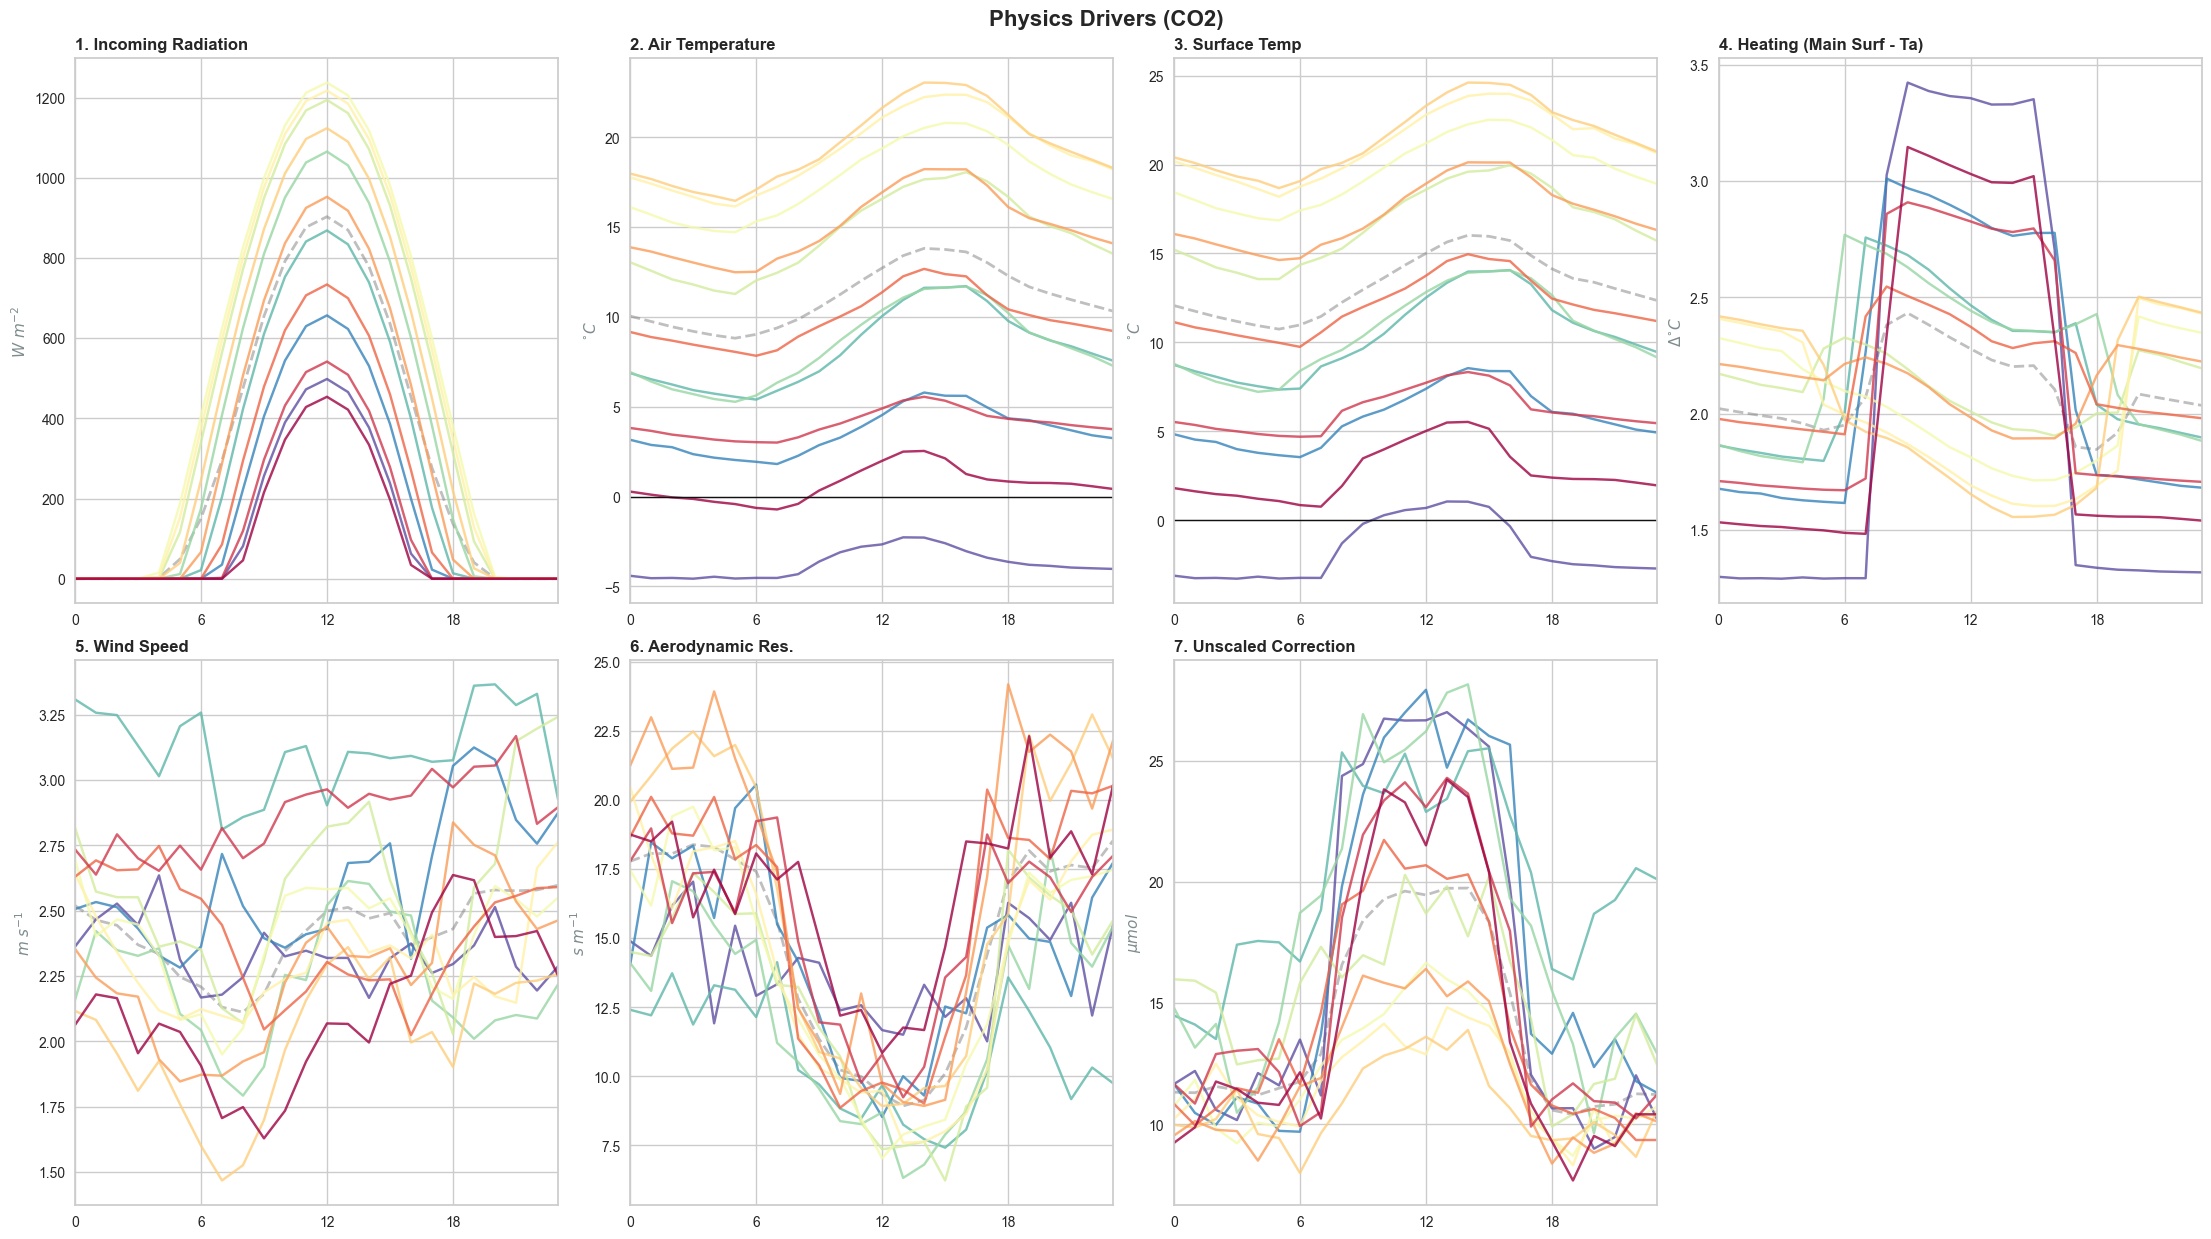

In [7]:
physics.plot_diel_cycles()

# Step 2: Optimize scaling factors with `ScopOptimizer`

Finished group 0.0 (Daytime 0.0): Median SF = 0.017
Finished group 1.0 (Daytime 0.0): Median SF = 0.029
Finished group 2.0 (Daytime 0.0): Median SF = 0.049
Finished group 3.0 (Daytime 0.0): Median SF = 0.060
Finished group 4.0 (Daytime 0.0): Median SF = 0.064
Finished group 5.0 (Daytime 0.0): Median SF = 0.075
Finished group 6.0 (Daytime 0.0): Median SF = 0.072
Finished group 7.0 (Daytime 0.0): Median SF = 0.087
Finished group 8.0 (Daytime 0.0): Median SF = 0.084
Finished group 9.0 (Daytime 0.0): Median SF = 0.092
Finished group 10.0 (Daytime 0.0): Median SF = 0.086
Finished group 11.0 (Daytime 0.0): Median SF = 0.081
Finished group 12.0 (Daytime 0.0): Median SF = 0.092
Finished group 13.0 (Daytime 0.0): Median SF = 0.072
Finished group 14.0 (Daytime 0.0): Median SF = 0.062
Finished group 15.0 (Daytime 0.0): Median SF = 0.073
Finished group 16.0 (Daytime 0.0): Median SF = 0.059
Finished group 17.0 (Daytime 0.0): Median SF = 0.061
Finished group 18.0 (Daytime 0.0): Median SF = 0.060
Fin

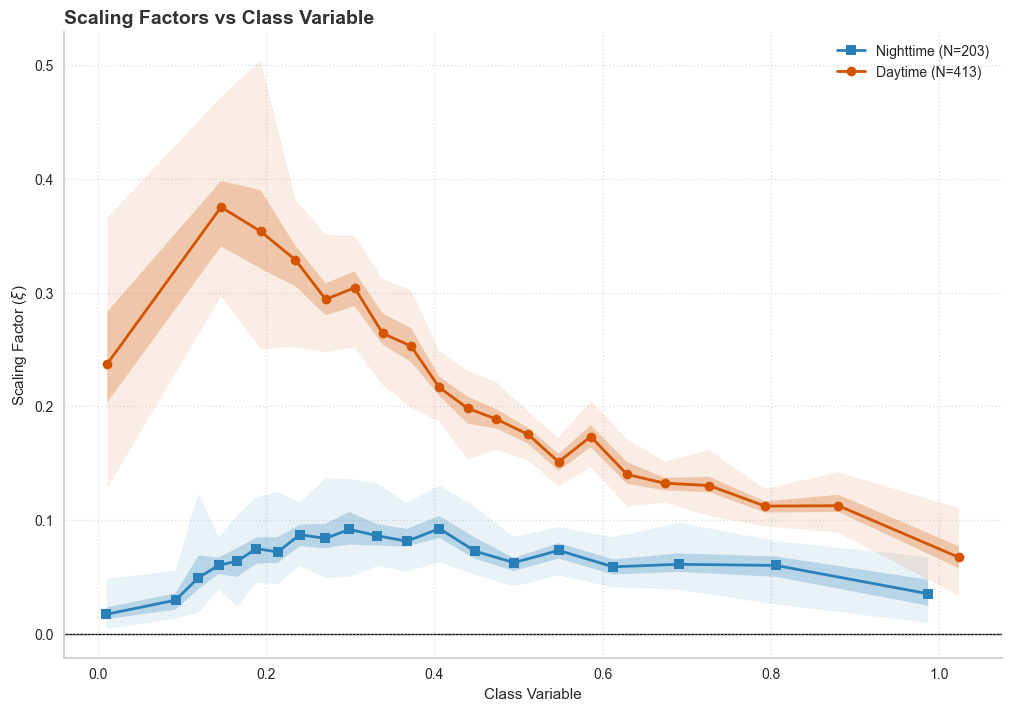

In [8]:
optimizer = ScopOptimizer(
    flux_type="CO2",
    fct_unsc=results_physics_df["FCT_UNSC_gfRF"],
    class_var=df["USTAR_IRGA72"].copy(),
    n_classes=20,
    n_bootstrap_runs=100,
    flux_openpath=df["NEE_L3.1_L3.2_QCF_IRGA75"].copy(),
    flux_closedpath=df["NEE_L3.1_L3.2_QCF_IRGA72"].copy(),
    daytime=results_physics_df["DAYTIME"]
)
scaling_factors_df = optimizer.run()
optimizer.stats()
optimizer.plot()

In [9]:
scaling_factors_df.describe()

,DAYTIME,GROUP_CLASSVAR,GROUP_CLASSVAR_MIN,GROUP_CLASSVAR_MAX,BOOTSTRAP_RUNS,SF_MEDIAN,SF_Q25,SF_Q75,SF_Q01,SF_Q99,SOS_MEDIAN,NUMVALS_AVG
count,40.00000,40.00000,40.000000,40.000000,40.0,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,0.50000,9.50000,0.424839,0.508984,100.0,0.137974,0.126712,0.149931,0.102492,0.180606,4773.465402,308.150000
std,0.50637,5.83974,0.259858,0.371883,0.0,0.096728,0.091613,0.101205,0.081448,0.114446,4060.775849,112.216035
min,0.00000,0.00000,0.009705,0.092042,100.0,0.016973,0.012761,0.022988,0.003822,0.048083,460.628098,74.000000
25%,0.00000,4.75000,0.229299,0.262597,100.0,0.066195,0.056881,0.076385,0.041329,0.108768,1046.252531,216.750000
50%,0.50000,9.50000,0.388810,0.422634,100.0,0.092005,0.081255,0.105255,0.061138,0.134041,3692.143018,281.500000
75%,1.00000,14.25000,0.592494,0.639979,100.0,0.191120,0.181556,0.200244,0.152719,0.223864,7915.096008,421.000000
max,1.00000,19.00000,1.023840,1.966410,100.0,0.375206,0.340628,0.398230,0.296463,0.504493,13115.501431,453.000000


In [10]:
optimizer.stats()



                    SCALING FACTOR OPTIMIZATION REPORT                     
Flux Type      : CO2
Bootstrap Runs : 100
Total Bins     : 40
---------------------------------------------------------------------------
1. GLOBAL SUMMARY (Median of Bins)      
...........................................................................
Period          |  Median SF | Mean Uncertainty (IQR) |    N_Avg
Nighttime       |      0.068 |                  0.019 |      203
Daytime         |      0.193 |                  0.028 |      413


2. DETAILED BIN BREAKDOWN               
...........................................................................
Bin  |     Class Range     |     N |    Median SF (ξ) |      99% CI      | Error (SOS)
---------------------------------------------------------------------------
--- DAYTIME ---
0    |     0.01 - 0.15     |   368 |            0.237 |   [0.13-0.37]    |   11083.47
1    |     0.15 - 0.19     |   394 |            0.375 |   [0.30-0.47]    |   10267.64
2 

Plotting Scaling Factors...


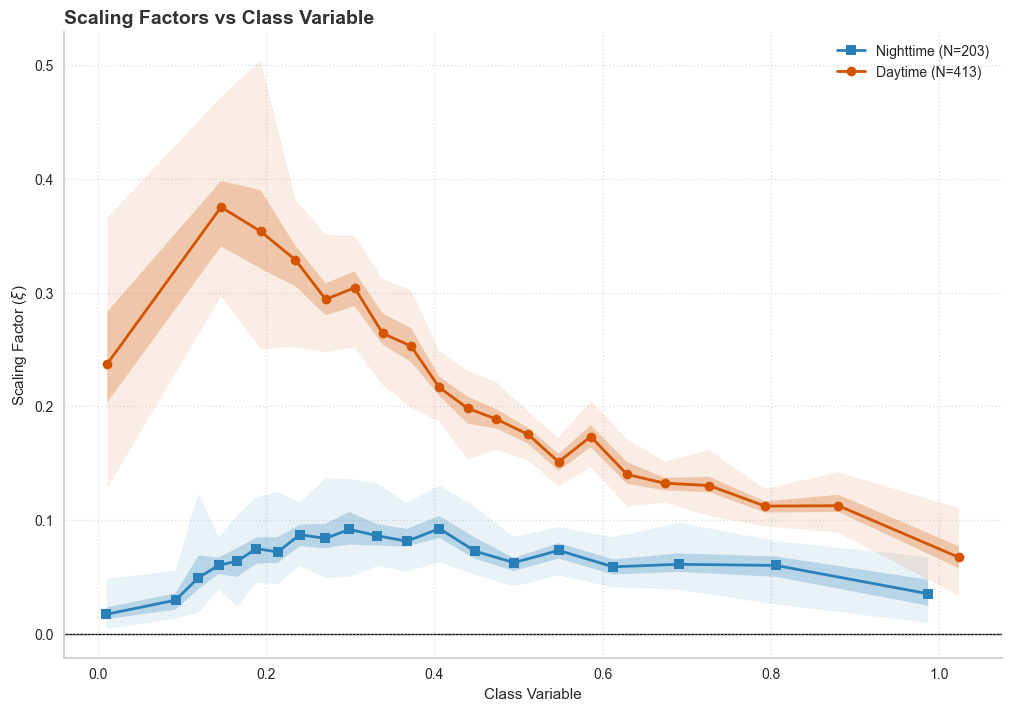

In [11]:
optimizer.plot()

# Step 3: Correct open-path fluxes with `ScopApplicator`

In [12]:
applicator = ScopApplicator(
    flux_type="CO2",
    fct_unsc=results_physics_df["FCT_UNSC_gfRF"],
    scaling_factors_df=scaling_factors_df,
    flux_openpath=df["NEE_L3.1_L3.2_QCF_IRGA75"].copy(),
    classvar=df["USTAR_IRGA72"].copy(),
    daytime=results_physics_df["DAYTIME"].copy()    
)
applicator.run()

(!) Warning: 252 fluxes missing Scaling Factor (due to missing USTAR_IRGA72).
    Imputing using Month-Daytime-Hour-Minute Diel Cycle Median...
    > Successfully imputed 252 missing Scaling Factors.


In [13]:
applicator.stats(flux_closedpath=df["NEE_L3.1_L3.2_QCF_IRGA72"])



                          FLUX CORRECTION REPORT                           
Flux Type      : CO2
Total Records  : 14,620
---------------------------------------------------------------------------
1. SCALING FACTOR ASSIGNMENT                                  (Method Used)
...........................................................................
   Direct Lookup (Valid USTAR_IRGA72) :   14,620  (100.0%)
 i Gap-Filled    (MDV Imputation) :        0  (  0.0%)

   Median Scaling Factor (Day)     : 0.198
   Median Scaling Factor (Night)   : 0.072


2. CORRECTION IMPACT (Budget)                                  (Units: Sum)
...........................................................................
   Uncorrected Sum                 :         -84,989
   Corrected Sum                   :         -55,179
   Net Adjustment                  :          29,809  (+35.1%)


3. ACCURACY vs REFERENCE                
...........................................................................
   Ref

Generating Comprehensive Flux Dashboard (Large Font Edition)...


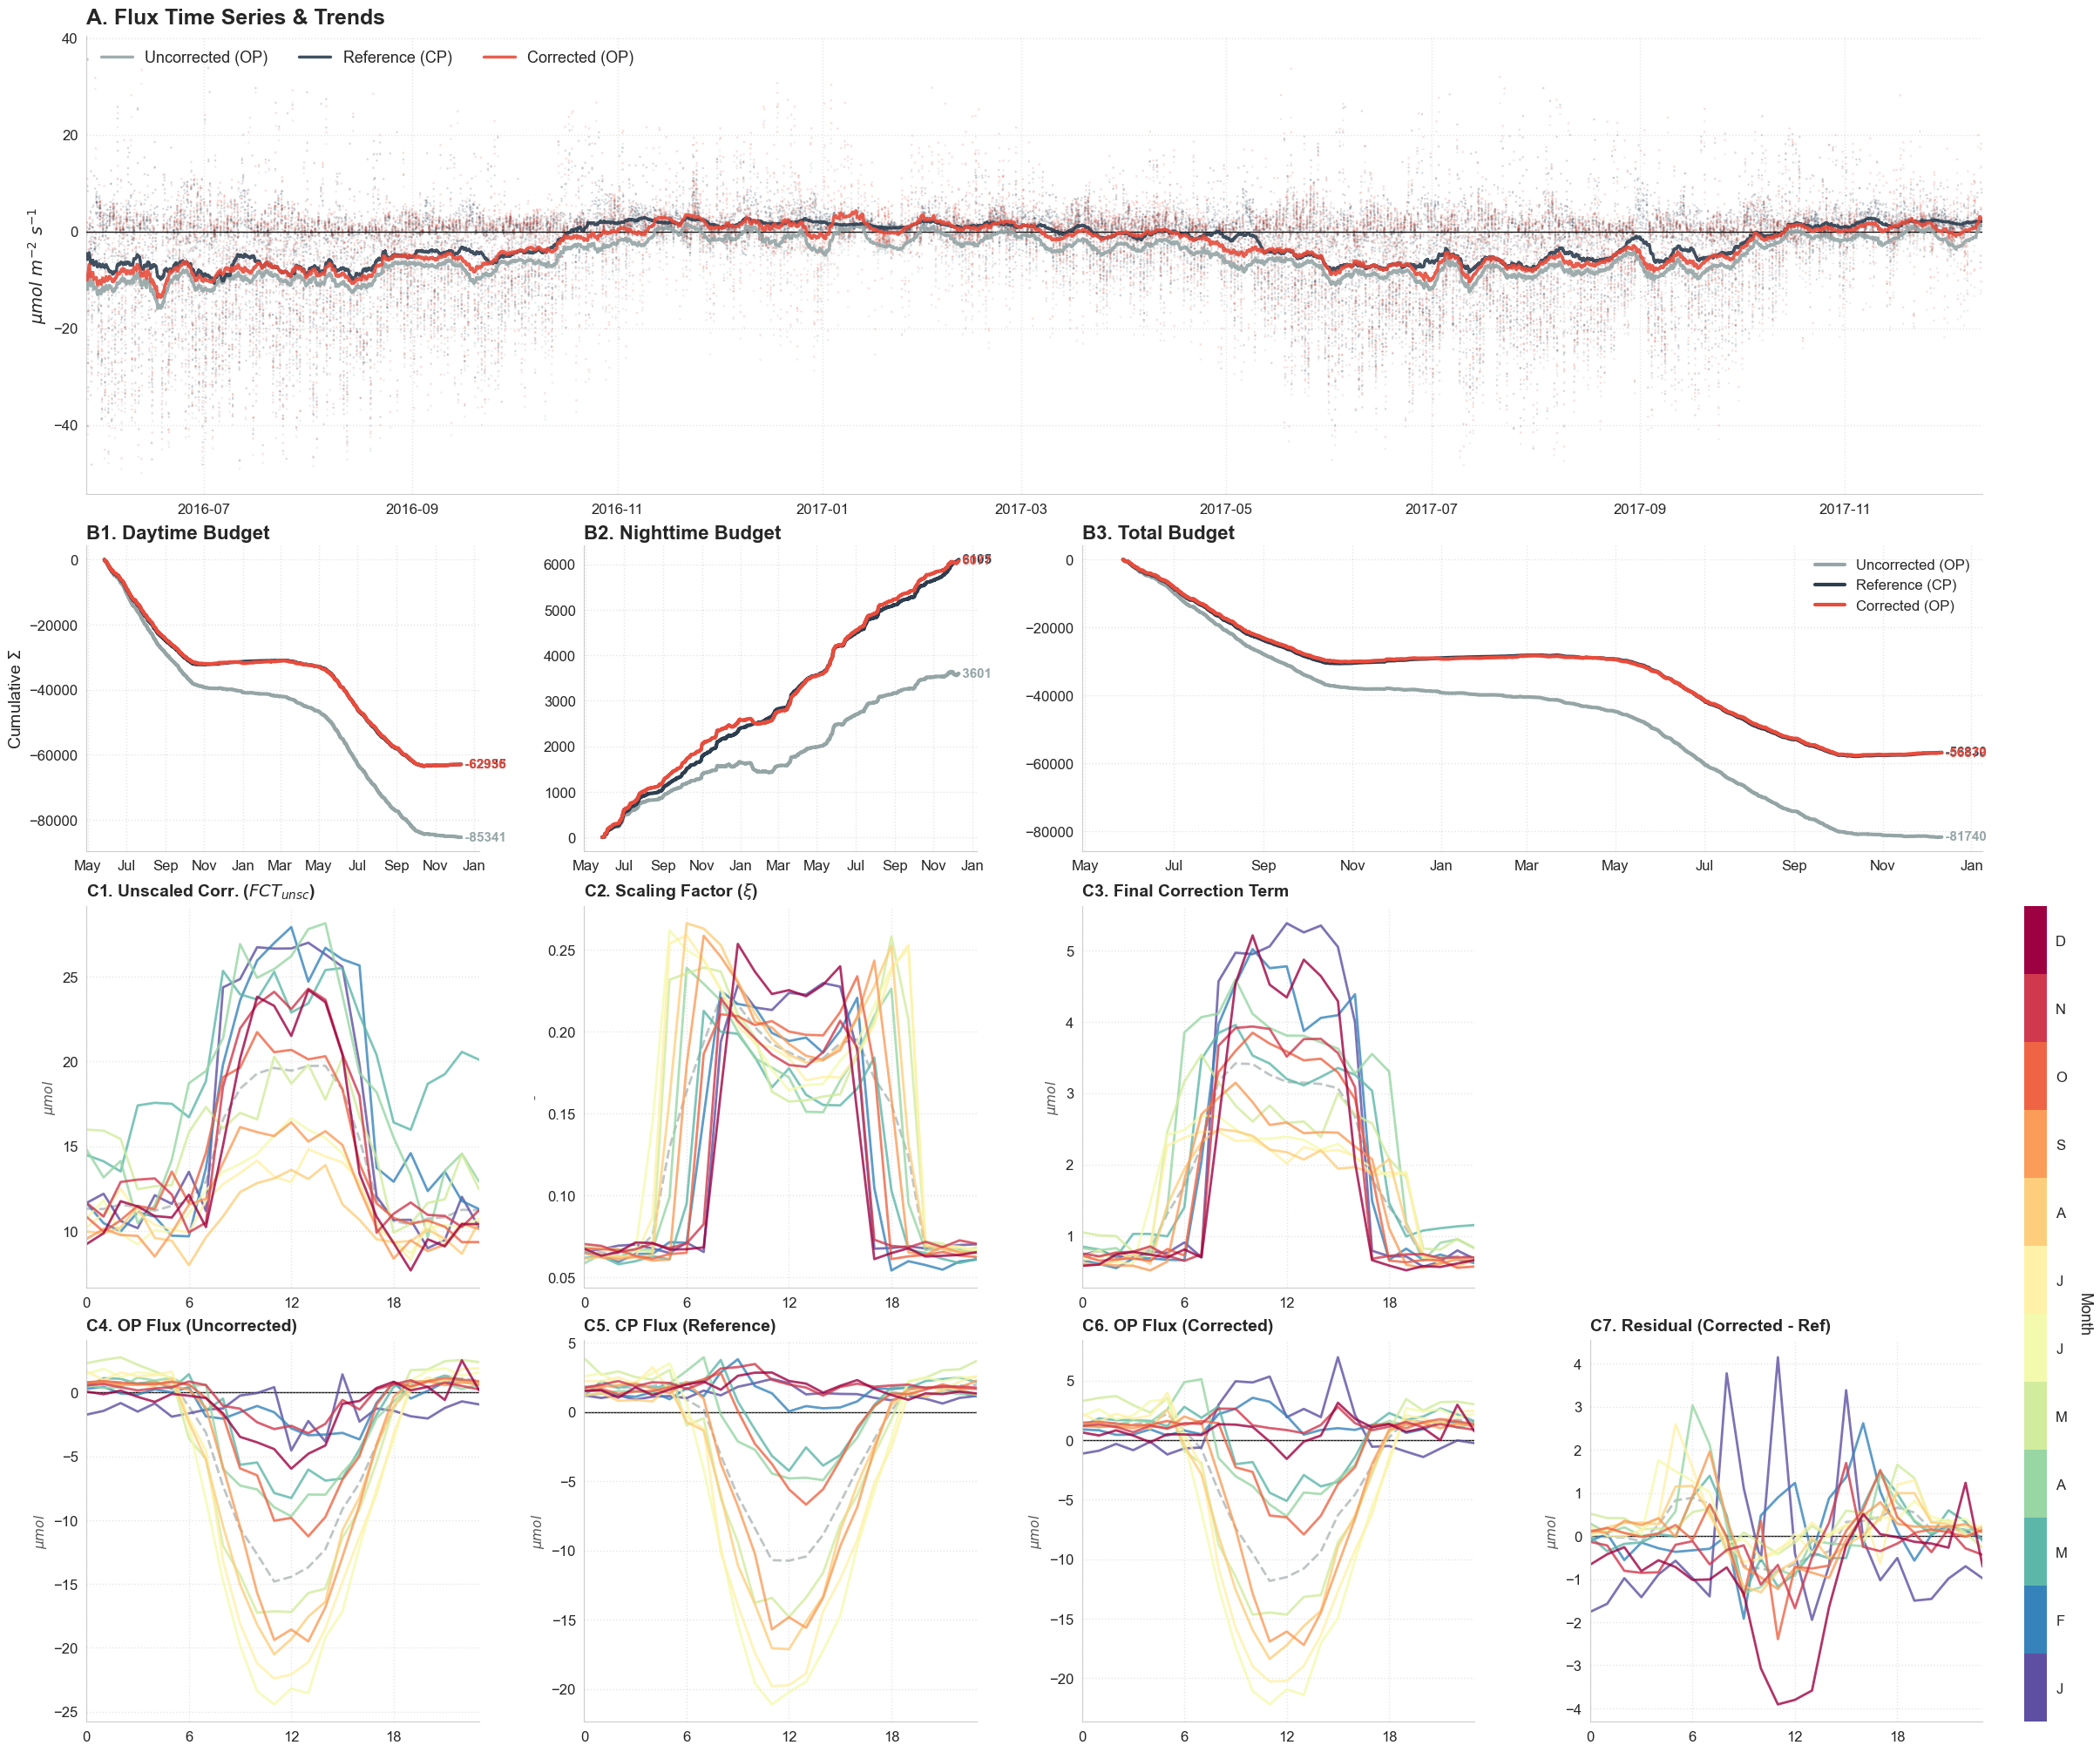

In [14]:
applicator.plot_dashboard(flux_closedpath=df["NEE_L3.1_L3.2_QCF_IRGA72"])

# Scaling factors table

In [15]:
scaling_factors_df

,DAYTIME,GROUP_CLASSVAR,GROUP_CLASSVAR_MIN,GROUP_CLASSVAR_MAX,BOOTSTRAP_RUNS,SF_MEDIAN,SF_Q25,SF_Q75,SF_Q01,SF_Q99,SOS_MEDIAN,NUMVALS_AVG
0,0.0,0.0,0.009705,0.092042,100,0.016973,0.012761,0.022988,0.003822,0.048083,587.830362,231
1,0.0,1.0,0.092100,0.118560,100,0.029399,0.021075,0.035533,0.013061,0.055320,728.977155,225
2,0.0,2.0,0.119289,0.143188,100,0.049233,0.039112,0.068600,0.018364,0.123256,1287.671825,239
3,0.0,3.0,0.143325,0.165168,100,0.060092,0.052410,0.067029,0.038686,0.085068,839.822373,230
4,0.0,4.0,0.165365,0.188061,100,0.063731,0.049846,0.075183,0.023922,0.104031,1340.235527,231
...,...,...,...,...,...,...,...,...,...,...,...,...
35,1.0,15.0,0.673752,0.726408,100,0.132327,0.126120,0.137104,0.115221,0.151358,7859.420807,453
36,1.0,16.0,0.726704,0.792686,100,0.130262,0.124359,0.137891,0.103369,0.161459,8238.457540,419
37,1.0,17.0,0.793117,0.880232,100,0.112175,0.106470,0.116309,0.094342,0.127351,6577.682106,421
38,1.0,18.0,0.880409,1.023690,100,0.112530,0.106976,0.122097,0.088693,0.141928,9456.339846,396


# Save to file

In [16]:
filename = "32_SelfHeatingCorrection_ScalingFactors_NEE-QCF11"
scaling_factors_df.to_csv(f"{filename}.csv", index=True)

# ✅END OF NOTEBOOK

In [17]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-12-04 16:28:37
